In [1]:
import pandas as pd
import numpy as pn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df["date_added"]=df["date_added"].str.strip()  #to remove extra spaces

In [9]:
df["date_added"]=pd.to_datetime(df["date_added"]) #to convert datetime

In [10]:
df.dropna(subset=["date_added"],inplace=True)

In [11]:
df["date_added"].isnull().sum()

np.int64(0)

C:\Users\home\AppData\Local\Temp\ipykernel_1456\2726446871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="type",palette="Set2")


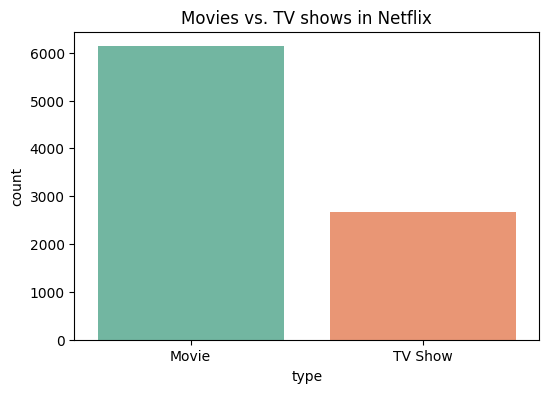

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="type",palette="Set2")
plt.title("Movies vs. TV shows in Netflix")
plt.show()

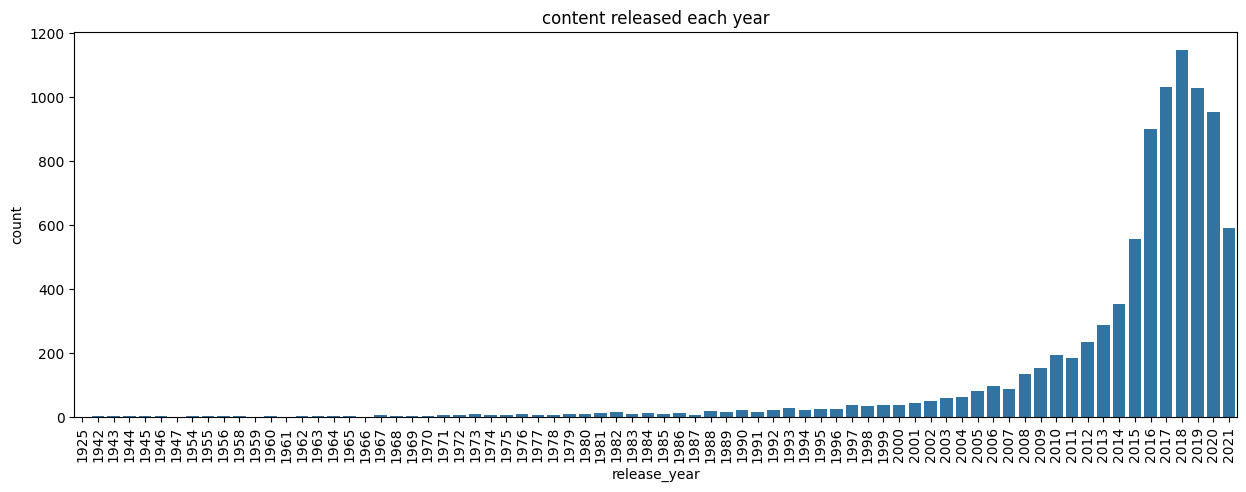

In [13]:
plt.figure(figsize=(15,5))

sns.countplot(data=df,x="release_year")
plt.xticks(rotation=90)
plt.title("content released each year")
plt.show()


In [14]:
df["director"]=df["director"].fillna("not available")
df["cast"]=df["cast"].fillna("not available")
df["country"]=df["country"].fillna("none")

In [15]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

In [16]:
#small missings so
df.dropna(subset=["rating"],inplace=True)
df.dropna(subset=["duration"],inplace=True)

In [17]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

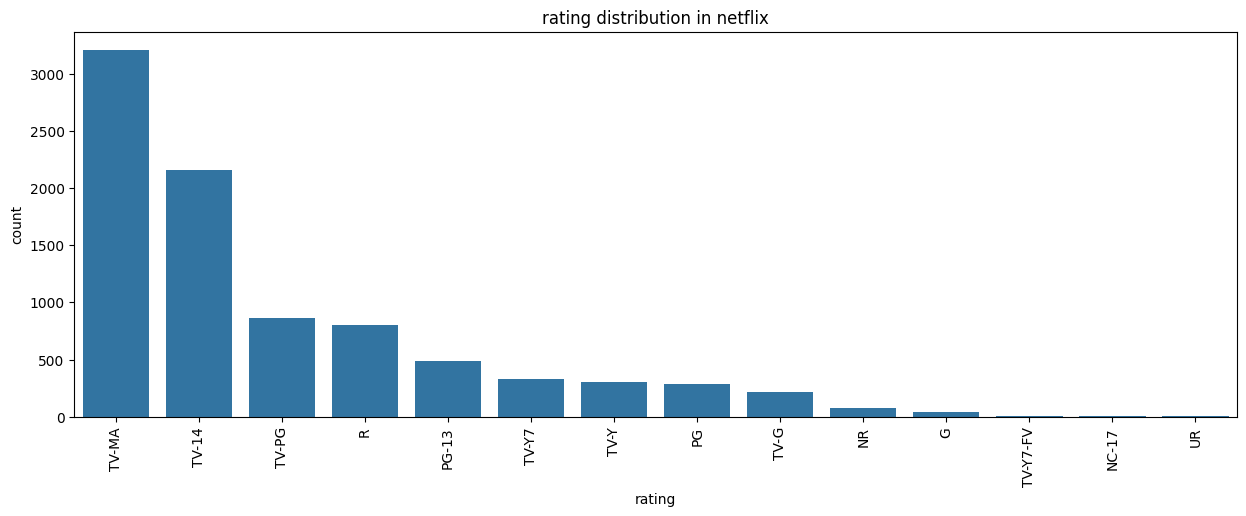

In [18]:
plt.figure(figsize=(15,5))
sns.countplot(data=df,x="rating",order=df["rating"].value_counts().index) #for proper graph
#sns.countplot(data=df,x="rating")
plt.title("rating distribution in netflix")
plt.xticks(rotation=90)
plt.show()

In [19]:
#genre analysis
df["listed_in"].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: str

In [20]:
#this is multiple categorical data
#split genres
genres=df["listed_in"].str.split(",")

In [21]:
#flatten all genres
all_genres=[]
for genre_list in genres:
    all_genres.extend(genre_list)
    

In [22]:
genre_counts=pd.Series(all_genres).value_counts()

In [23]:
genre_counts.head(10)

 International Movies     2624
Dramas                    1599
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     773
 Independent Movies        736
 TV Dramas                 695
 Romantic Movies           613
Name: count, dtype: int64

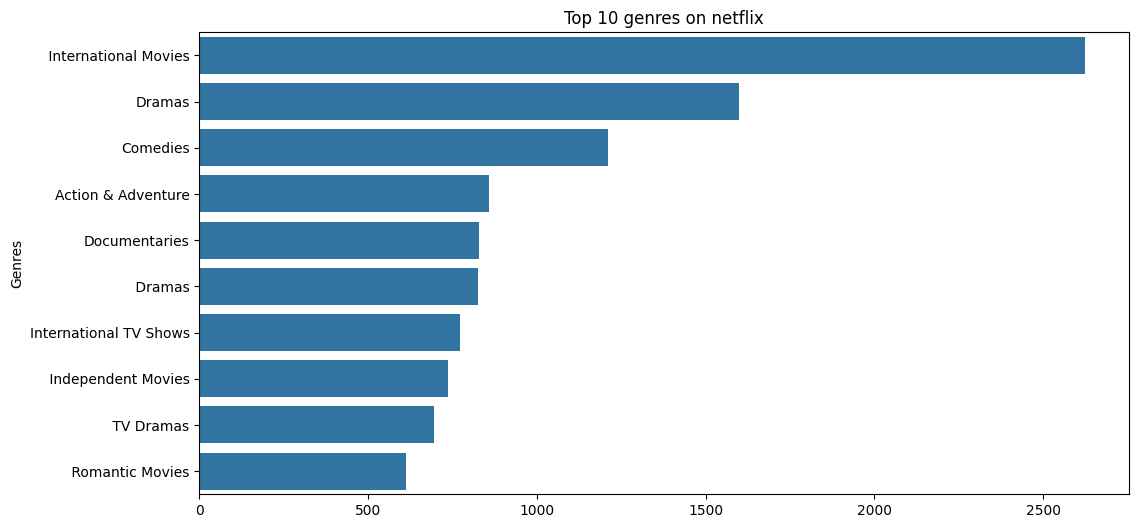

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.head(10).values,y=genre_counts.head(10).index)
plt.title("Top 10 genres on netflix")
plt.ylabel("Genres")
plt.show()

In [25]:
country_counts=df["country"].value_counts().head(10)
country_counts

country
United States     2809
India              972
none               829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

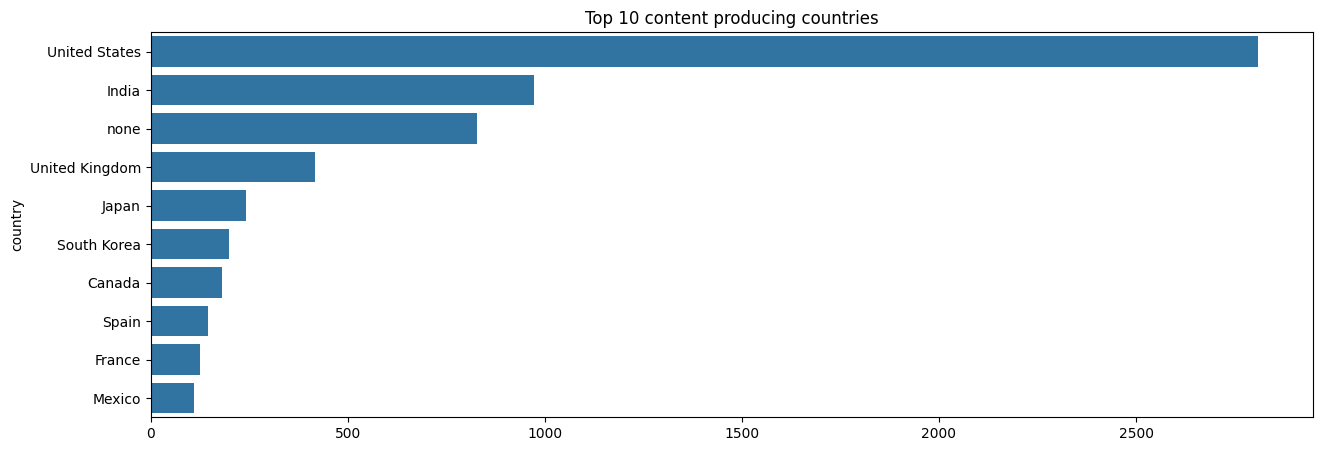

In [26]:
plt.figure(figsize=(15,5))
sns.barplot(x=country_counts.values,y=country_counts.index)
plt.title("Top 10 content producing countries")
plt.show()

In [27]:
content_by_year=df["release_year"].value_counts().sort_index()

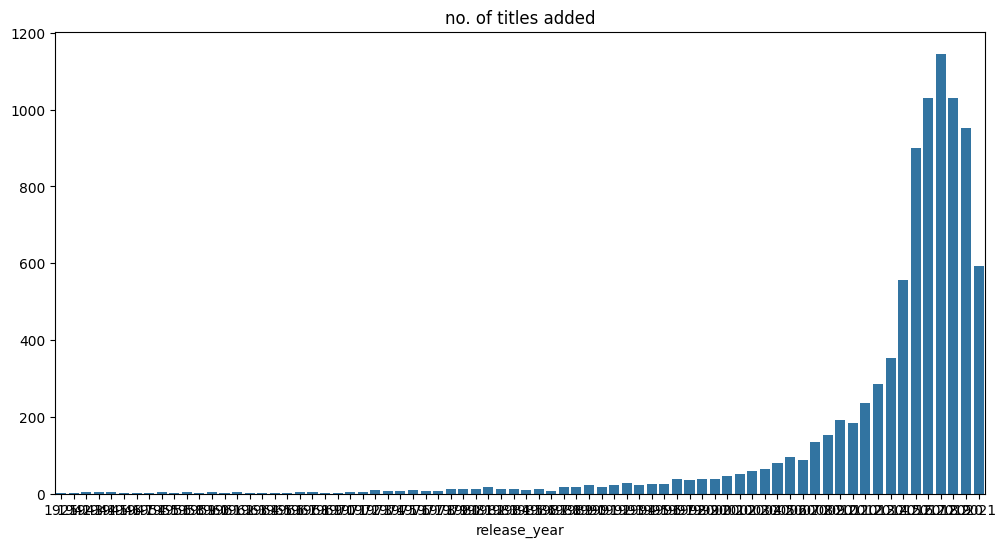

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(x=content_by_year.index,y=content_by_year.values)
plt.title("no. of titles added")
plt.show()

In [29]:
#topics covered till now: 
#data loading
#data cleaning
#EDA
#genre analysis
#trnd analysis

In [30]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,not available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",none,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,not available,not available,none,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,not available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,not available,not available,none,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [31]:
df['duration'].head(10)

0       90 min
1    2 Seasons
2     1 Season
3     1 Season
4    2 Seasons
5     1 Season
6       91 min
7      125 min
8    9 Seasons
9      104 min
Name: duration, dtype: str

In [32]:
movies_df=df[df['type']=='Movie']

In [33]:
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",none,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [34]:
movies_df['type'].value_counts()

type
Movie    6126
Name: count, dtype: int64

In [35]:
movies_df['duration']=movies_df['duration'].str.replace('min','')

In [36]:
movies_df['duration']=movies_df['duration'].astype('int64')

In [37]:
movies_df['duration'].head(10)

0      90
6      91
7     125
9     104
12    127
13     91
16     67
18     94
22    161
23     61
Name: duration, dtype: int64

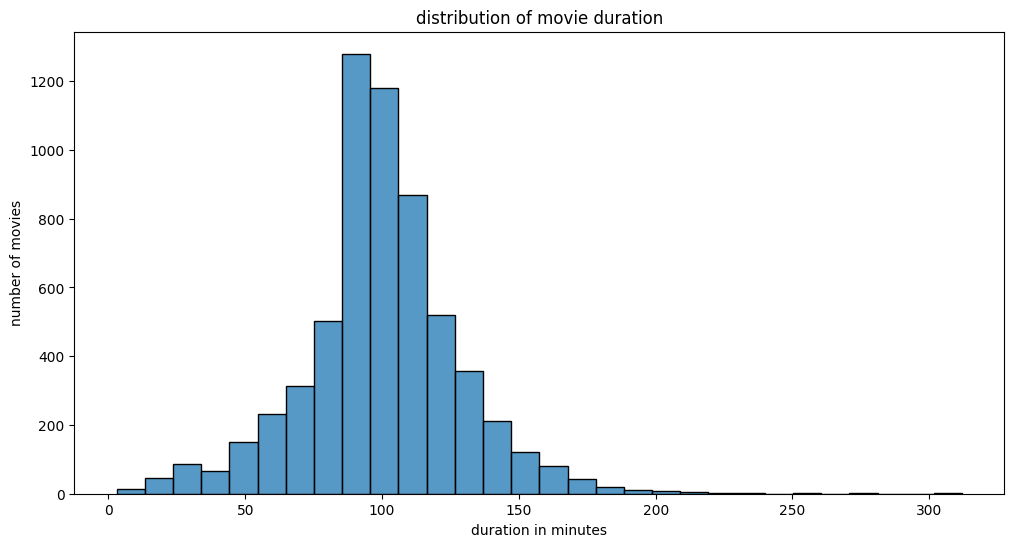

In [38]:
plt.figure(figsize=(12,6))
sns.histplot(movies_df['duration'],bins=30)
plt.title("distribution of movie duration")
plt.xlabel("duration in minutes")
plt.ylabel("number of movies")
plt.show()

In [39]:
df['director'].head(10)


0                  Kirsten Johnson
1                    not available
2                  Julien Leclercq
3                    not available
4                    not available
5                    Mike Flanagan
6    Robert Cullen, José Luis Ucha
7                     Haile Gerima
8                  Andy Devonshire
9                   Theodore Melfi
Name: director, dtype: str

In [40]:
director_df=df[df['director']!='not available']

In [41]:
directors=director_df['director'].str.split(', ')

In [42]:
all_directors=[]
for director_list in directors:
    all_directors.extend(director_list)
    

In [43]:
director_counts=pd.Series(all_directors).value_counts()

In [44]:
director_counts.head(10)

Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

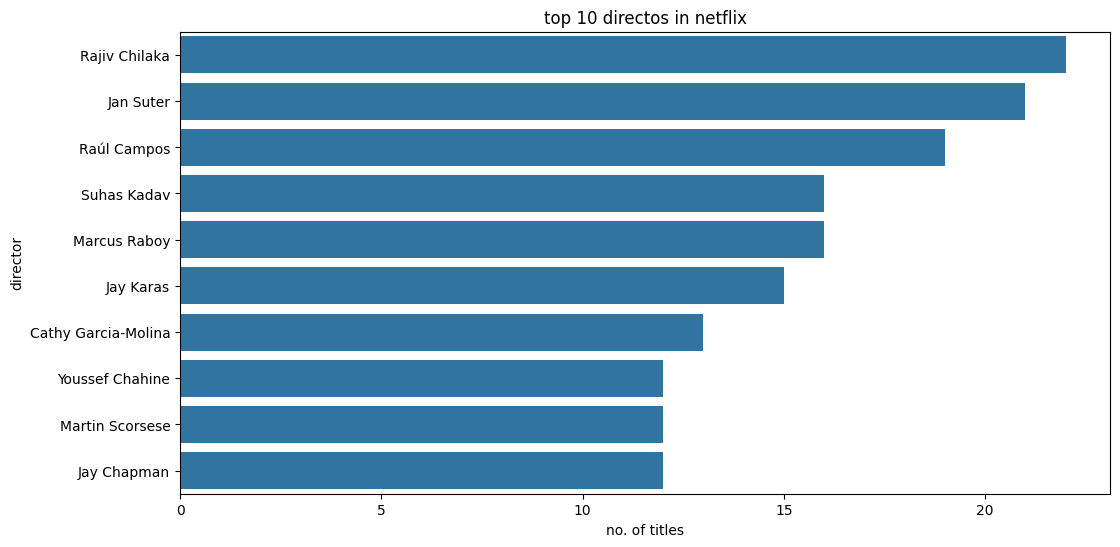

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=director_counts.head(10).values,
    y=director_counts.head(10).index
)
plt.title("top 10 directos in netflix")
plt.xlabel("no. of titles")
plt.ylabel("director")
plt.show()

In [ ]:
movies_df[['release_year','duration']].head()


,release_year,duration
0,2020,90
6,2021,91
7,1993,125
9,2021,104
12,2021,127


In [ ]:
movies_df[['release_year','duration']].corr()


,release_year,duration
release_year,1.000000,-0.206248
duration,-0.206248,1.000000


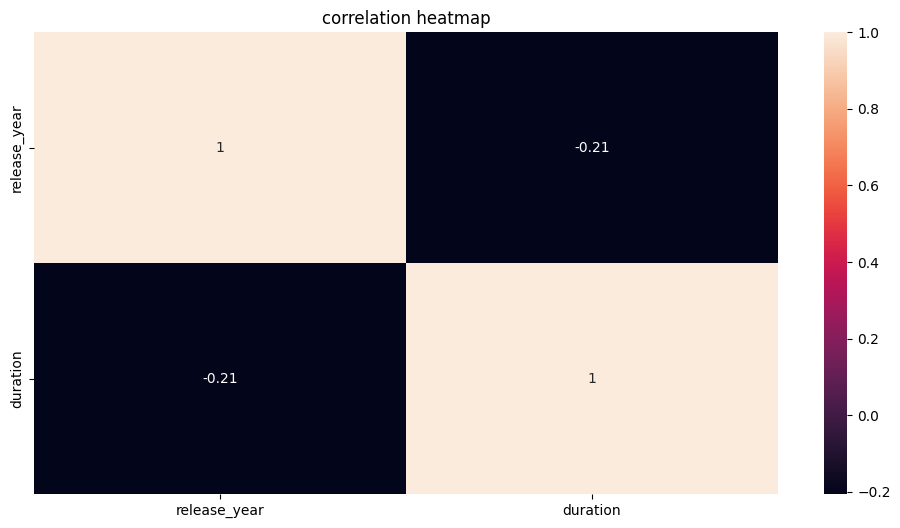

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(movies_df[['release_year','duration']].corr(),annot=True)
plt.title("correlation heatmap")
plt.show()